In [3]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from train_test_split import load_grouped_splits
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Load premade splits
`python
data = tuple(X_train, y_train, X_val, y_val, X_test, y_test, class_names)

In [4]:
data = load_grouped_splits()
X_train, y_train, X_val, y_val, X_test, y_test, classes = data

# Concatenate training and validation sets to do CV on combined set
X_train_val = np.vstack((X_train, X_val))
y_train_val = np.hstack((y_train, y_val))
print(X_train.shape)
print("Classes:")
print(classes)

Train size: 96
Validation size: 24
Test size: 32
(96, 16384)
Classes:
['Anger' 'Contempt' 'Disgust' 'Fear' 'Happy' 'Neutral' 'Sad' 'Surprised']


### Grid search with CV for best Decision Tree hyperparameters
Must have PCA in pipeline so it is not fit on val set.

In [5]:
# Put pca in grid search so it is fitted on only the train sets, this way the val sets will act like a real unseen set
pipeline = Pipeline([
    ('pca', PCA()),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# params for search
param_grid = {
    'pca__n_components': [0.99],
    'classifier__max_depth': [10],
    'classifier__min_samples_split': [2],
    'classifier__min_samples_leaf': [2],
    'classifier__max_features': [None]
}
grid_search = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1, verbose=3, scoring='accuracy')

In [6]:
grid_search.fit(X_train_val, y_train_val)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__max_depth': [10], 'classifier__max_features': [None], 'classifier__min_samples_leaf': [2], 'classifier__min_samples_split': [2], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_components,0.99


### Best parameters found:
- PCA variance retention: 99%
- max_depth: 10
- min_samples_split: 2
- min_samples_leaf: 2
- max_features: None


In [7]:
X_train_val_pred = grid_search.best_estimator_.predict(X_train_val)
train_accuracy = accuracy_score(y_train_val, X_train_val_pred)
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Training Accuracy with best parameters: {train_accuracy}")
print(grid_search.best_score_)

Best parameters found: {'classifier__max_depth': 10, 'classifier__max_features': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'pca__n_components': 0.99}
Training Accuracy with best parameters: 0.85
0.2833333333333333


Test Accuracy: 0.125
Classification Report:
              precision    recall  f1-score   support

       Anger       0.00      0.00      0.00         4
    Contempt       0.00      0.00      0.00         4
     Disgust       0.00      0.00      0.00         4
        Fear       0.22      0.50      0.31         4
       Happy       0.20      0.50      0.29         4
     Neutral       0.00      0.00      0.00         4
         Sad       0.00      0.00      0.00         4
   Surprised       0.00      0.00      0.00         4

    accuracy                           0.12        32
   macro avg       0.05      0.12      0.07        32
weighted avg       0.05      0.12      0.07        32

Confusion Matrix:


c:\Users\baklu\Documents\NTNU\IT3212\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\baklu\Documents\NTNU\IT3212\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\baklu\Documents\NTNU\IT3212\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

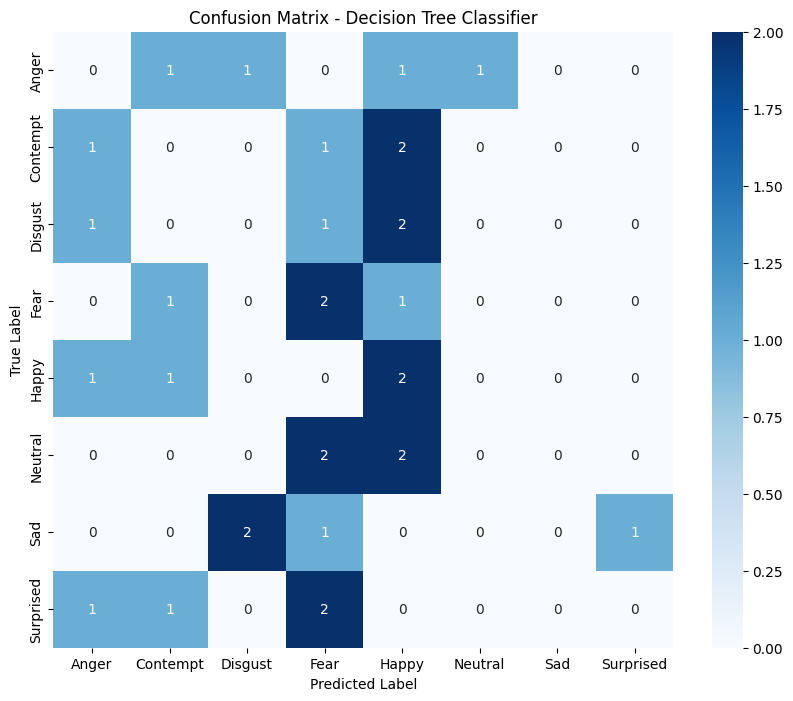

In [8]:

y_test_pred = grid_search.best_estimator_.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy}")
print("Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=classes))
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix - Decision Tree Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()